In [1]:
!pip install -q imageio
!pip install -q opencv-python
!pip install -q git+https://github.com/tensorflow/docs

  Preparing metadata (setup.py) ... done


In [2]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow_docs.vis import embed
import numpy as np
import cv2

# Import matplotlib libraries
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patches as patches

import matplotlib.pyplot as plt

from PIL import Image
import tensorflow as tf
import tensorflow.keras.backend as K
from google.colab.patches import cv2_imshow
from tensorflow.python.ops.numpy_ops import np_config
import pandas as pd
# Some modules to display an animation using imageio.
import imageio
from IPython.display import HTML, display

# loading the data

In [3]:
trueData=np.load('push-upT.npy')
falseData=np.load('push-upF.npy')

# Data Analysis

In [4]:
trueData=np.squeeze(trueData)
falseData=np.squeeze(falseData)

In [5]:
trueLabes=np.ones((trueData.shape[0],1))
falseLabels=np.zeros((falseData.shape[0],1))

In [6]:
def mean_std_x_y(data):
  # calculate the mean x and y values for each keypoint separately
  mean_x = np.mean(data[:,:,0], axis=0)
  mean_y = np.mean(data[:,:,1], axis=0)

  # define the connections between keypoints
  connections = [(0,1), (0,2), (1,3), (2,4), (0,5), (0,6), (5,7), (7,9), (6,8), (8,10), (5,6), (5,11), (6,12), (11,12), (11,13), (13,15), (12,14), (14,16)]
  # specify the size of the figure
  plt.figure(figsize=(8, 6))
  # plot the mean x and y values for each keypoint and connect them
  for i, (x, y) in enumerate(zip(mean_x, mean_y)):
      plt.scatter(x, y)
      for a, b in connections:
          plt.plot([mean_x[a], mean_x[b]], [mean_y[a], mean_y[b]], color='gray', linestyle='-', linewidth=1)

  plt.xlabel('Mean X')
  plt.ylabel('Mean Y')
  plt.legend()
#########################################################################################

  # calculate the standard deviation of the x and y values for each keypoint separately
  std_x = np.std(data[:,:,0], axis=0)
  std_y = np.std(data[:,:,1], axis=0)

  # create a bar chart of the standard deviation of the x and y values for each keypoint
  x = np.arange(17)
  width = 0.35
  fig, ax = plt.subplots()
  rects1 = ax.bar(x - width/2, std_x, width, label='X')
  rects2 = ax.bar(x + width/2, std_y, width, label='Y')
  ax.set_xlabel('Keypoint')
  ax.set_ylabel('Standard deviation')
  ax.set_title('Standard deviation of X and Y values for each keypoint')
  ax.set_xticks(x)
  ax.legend()
  plt.show()



In [7]:
def heatmap_x_y(data):
  # create a heatmap of the distribution of keypoints
  fig, ax = plt.subplots()
  hist = ax.hist2d(data[:,:,0].flatten(), data[:,:,1].flatten(), bins=50)
  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_title('Heatmap of the distribution of keypoints')
  fig.colorbar(hist[3], ax=ax)
  plt.show()

In [8]:
def mean_std_confi(data):
  # calculate the mean confidence for each keypoint separately
  mean_conf = np.mean(data[:,:,2], axis=0)

  # create a bar chart of the mean confidence for each keypoint
  x = np.arange(17)
  width = 0.35
  fig, ax = plt.subplots()
  rects1 = ax.bar(x, mean_conf, width)
  ax.set_xlabel('Keypoint')
  ax.set_ylabel('Mean confidence')
  ax.set_title('Mean confidence for each keypoint')
  ax.set_xticks(x)
  plt.show()
############################################################################
  # calculate the standard deviation of the confidence for each keypoint separately
  std_conf = np.std(data[:,:,2], axis=0)

  # create a bar chart of the standard deviation of the confidence for each keypoint
  x = np.arange(17)
  width = 0.35
  fig, ax = plt.subplots()
  rects1 = ax.bar(x, std_conf, width)
  ax.set_xlabel('Keypoint')
  ax.set_ylabel('Standard deviation')
  ax.set_title('Standard deviation of confidence for each keypoint')
  ax.set_xticks(x)
  plt.show()

# True Data

<ipython-input-6-b9fbf47a67e0>:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


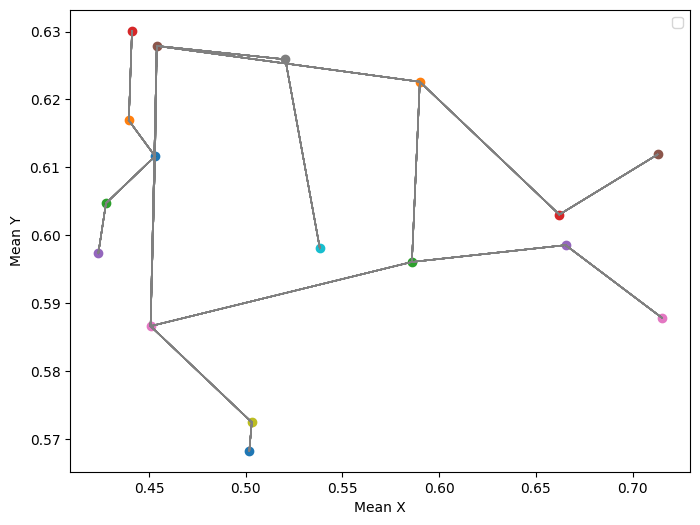

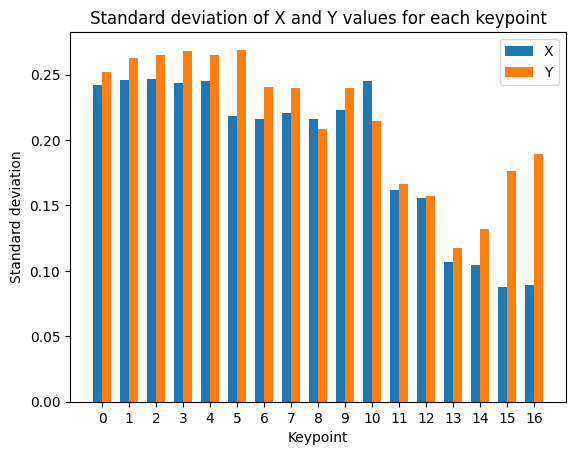

In [9]:
mean_std_x_y(trueData)

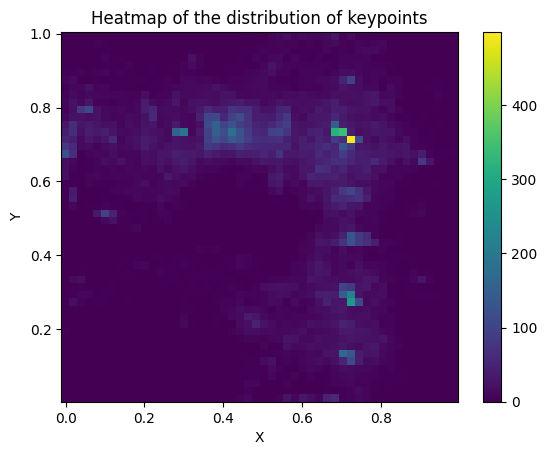

In [10]:
heatmap_x_y(trueData)

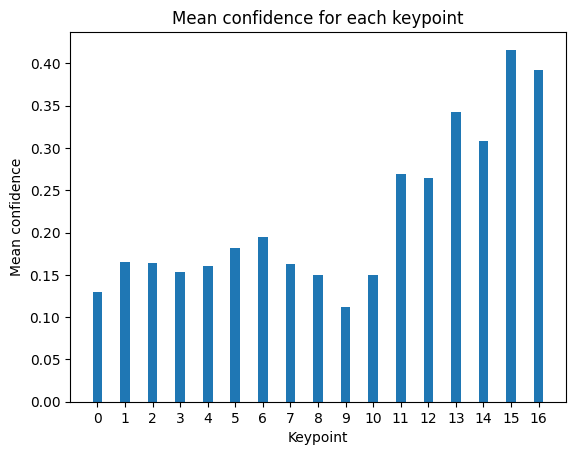

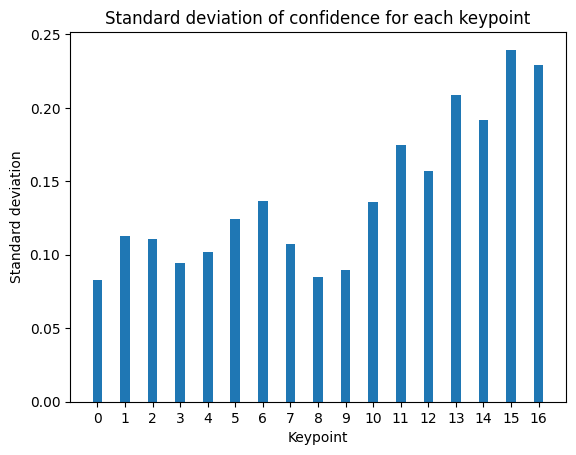

In [11]:
mean_std_confi(trueData)

# False Data

<ipython-input-6-b9fbf47a67e0>:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


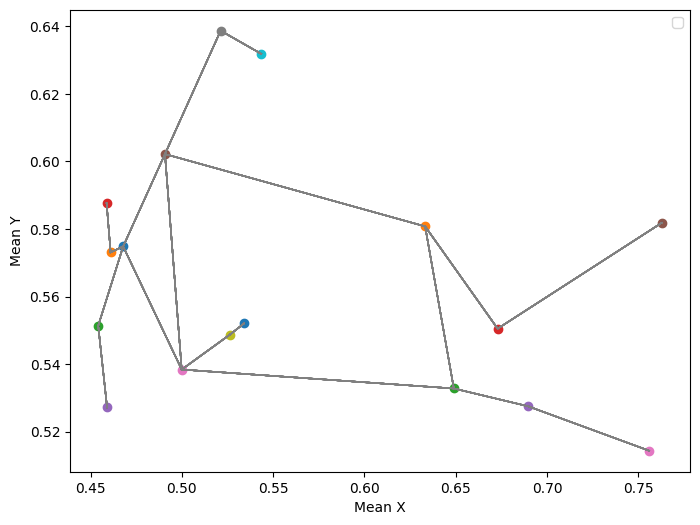

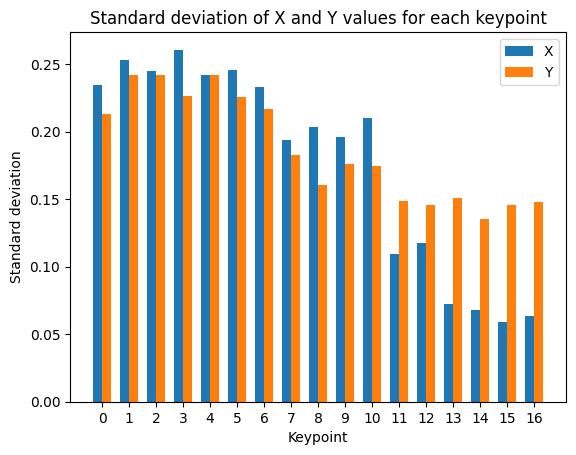

In [12]:
mean_std_x_y(falseData)

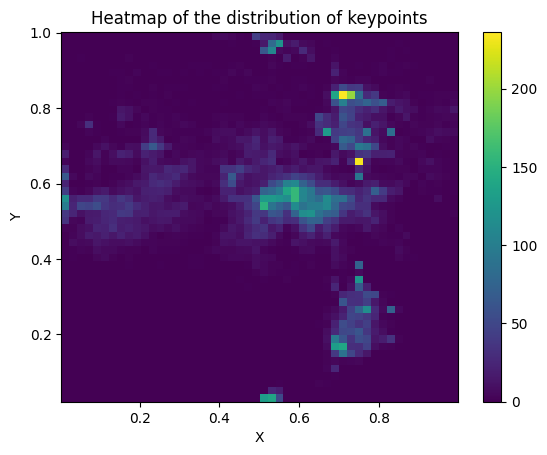

In [13]:
heatmap_x_y(falseData)

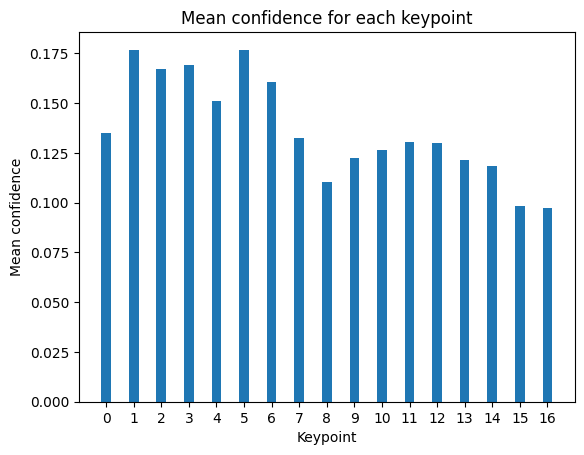

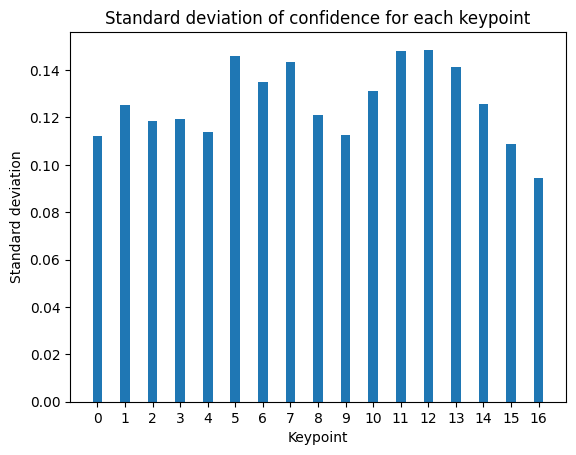

In [14]:
mean_std_confi(falseData)

# Generating The Dataset

In [15]:
Data=np.concatenate((trueData, falseData))
labels=np.concatenate((trueLabes, falseLabels))
Data=Data.reshape((Data.shape[0], -1))

In [16]:
dataSet = pd.DataFrame(Data)
dataSet['Label'] = labels
print(dataSet)


             0         1         2         3         4         5         6  \
0     0.747617  0.027183  0.174259  0.748045  0.014124  0.246906  0.743853   
1     0.751827  0.026958  0.163232  0.763970  0.014111  0.258530  0.747115   
2     0.750515  0.041016  0.155581  0.762055  0.016690  0.233119  0.744263   
3     0.765065  0.030398  0.177163  0.764575  0.016468  0.238537  0.747152   
4     0.748946  0.028378  0.167683  0.760741  0.014341  0.241328  0.731145   
...        ...       ...       ...       ...       ...       ...       ...   
2907  0.160294  0.560444  0.037392  0.011149  0.578996  0.156516  0.013168   
2908  0.168252  0.559679  0.037502  0.016397  0.557096  0.130574  0.126451   
2909  0.198551  0.552769  0.027209  0.014954  0.555936  0.128349  0.154506   
2910  0.198691  0.538245  0.028109  0.016653  0.554594  0.128319  0.155009   
2911  0.177285  0.542216  0.031445  0.014156  0.557679  0.124333  0.150364   

             7         8         9  ...        42        43    

In [17]:
dataSet = dataSet.sample(frac=1).reset_index(drop=True)
print(dataSet)

             0         1         2         3         4         5         6  \
0     0.205348  0.827426  0.275220  0.195336  0.816465  0.474760  0.197388   
1     0.751375  0.240445  0.069068  0.729688  0.213378  0.131370  0.709688   
2     0.255366  0.600269  0.009787  0.514941  0.995291  0.073077  0.487135   
3     0.747173  0.205730  0.189301  0.742743  0.209551  0.209475  0.744661   
4     0.405342  0.727059  0.163323  0.390131  0.708498  0.229407  0.391142   
...        ...       ...       ...       ...       ...       ...       ...   
2907  0.541739  0.573782  0.068523  0.516016  0.566049  0.138279  0.485720   
2908  0.613906  0.577037  0.037321  0.589234  0.571550  0.058164  0.584141   
2909  0.376017  0.750187  0.149747  0.356679  0.752118  0.175932  0.357565   
2910  0.522322  0.560452  0.153515  0.512555  0.558791  0.202604  0.509907   
2911  0.266006  0.667529  0.043972  0.264484  0.674051  0.042347  0.250167   

             7         8         9  ...        42        43    

In [18]:
dataSet.dropna(inplace=True) # removes rows with missing data
dataSet.drop_duplicates(inplace=True) # removes duplicate rows

In [19]:
dataSet

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,Label
0,0.205348,0.827426,0.275220,0.195336,0.816465,0.474760,0.197388,0.809876,0.422186,0.210393,...,0.563701,0.775450,0.451157,0.690452,0.731348,0.454515,0.699486,0.748497,0.635765,1.0
1,0.751375,0.240445,0.069068,0.729688,0.213378,0.131370,0.709688,0.205803,0.145930,0.735278,...,0.697023,0.531289,0.317336,0.724627,0.717303,0.776440,0.684442,0.566733,0.244870,1.0
2,0.255366,0.600269,0.009787,0.514941,0.995291,0.073077,0.487135,0.994042,0.088506,0.182491,...,0.679814,0.457245,0.042237,0.776627,0.676185,0.085475,0.685990,0.446651,0.049736,0.0
3,0.747173,0.205730,0.189301,0.742743,0.209551,0.209475,0.744661,0.204884,0.174556,0.743247,...,0.787734,0.208488,0.112653,0.827484,0.202154,0.038112,0.810523,0.263956,0.033872,0.0
4,0.405342,0.727059,0.163323,0.390131,0.708498,0.229407,0.391142,0.736803,0.157125,0.394242,...,0.697513,0.704569,0.151795,0.763690,0.653355,0.090523,0.778129,0.676817,0.096337,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2907,0.541739,0.573782,0.068523,0.516016,0.566049,0.138279,0.485720,0.565006,0.141759,0.549431,...,0.682271,0.566139,0.062510,0.721794,0.554778,0.024748,0.820831,0.684284,0.115991,0.0
2908,0.613906,0.577037,0.037321,0.589234,0.571550,0.058164,0.584141,0.560980,0.086674,0.732463,...,0.682973,0.531065,0.032866,0.669036,0.543649,0.024835,0.651446,0.532794,0.013985,0.0
2909,0.376017,0.750187,0.149747,0.356679,0.752118,0.175932,0.357565,0.758487,0.151672,0.355049,...,0.777500,0.739571,0.054232,0.856857,0.694466,0.015990,0.859049,0.713696,0.019318,1.0
2910,0.522322,0.560452,0.153515,0.512555,0.558791,0.202604,0.509907,0.564609,0.133424,0.533903,...,0.651093,0.557798,0.031981,0.732664,0.486946,0.012992,0.716095,0.525417,0.015861,0.0


# spliting the dataset


In [20]:
from sklearn.model_selection import train_test_split
train_val_data, test_data = train_test_split(dataSet, test_size=0.2, random_state=42)  # 80% train/validation, 20% test
train_data, val_data = train_test_split(train_val_data, test_size=0.25, random_state=42)  # 60% train, 20% validation
print(test_data)

             0         1         2         3         4         5         6  \
178   0.395931  0.743575  0.208498  0.380095  0.734617  0.364594  0.374728   
678   0.828840  0.823190  0.181337  0.825407  0.827166  0.230147  0.827485   
2872  0.014196  0.550120  0.195344  0.007382  0.560185  0.214010  0.006359   
2845  0.674919  0.752345  0.282573  0.661650  0.757010  0.303822  0.661758   
1898  0.019483  0.675702  0.064278  0.011855  0.683247  0.060509  0.006486   
...        ...       ...       ...       ...       ...       ...       ...   
1221  0.212150  0.466603  0.019523  0.029169  0.514792  0.091229  0.154354   
542   0.390288  0.770325  0.145757  0.367083  0.768901  0.090200  0.367134   
2313  0.591094  0.363416  0.096866  0.721322  0.328284  0.018546  0.724107   
1644  0.274823  0.720565  0.056468  0.262229  0.717422  0.061950  0.246115   
1591  0.054580  0.709371  0.040275  0.038320  0.743144  0.034663  0.005599   

             7         8         9  ...        42        43    

In [21]:
xtrain=train_data.iloc[:, :51].values
ytrain=train_data['Label'].values
xtest=test_data.iloc[:, :51].values
ytest=test_data['Label'].values
xval=val_data.iloc[:, :51].values
yval=val_data['Label'].values

In [22]:
xtrain=xtrain.reshape((xtrain.shape[0], 17,3))
xtest=xtest.reshape((xtest.shape[0], 17,3))
xval=xval.reshape((xval.shape[0], 17,3))

# Form Correctness Model

In [23]:
import tensorflow as tf

# Define the input shape
input_shape = (17,3)

# Create a sequential model
model = tf.keras.models.Sequential()

# Add a flatten layer to flatten the input into a vector
model.add(tf.keras.layers.Flatten(input_shape=input_shape))

# Add a dense layer with 64 nodes, using ReLU activation
model.add(tf.keras.layers.Dense(64, activation='relu'))

# Add a dropout layer to prevent overfitting
model.add(tf.keras.layers.Dropout(0.2))

# Add another dense layer with 32 nodes, using ReLU activation
model.add(tf.keras.layers.Dense(32, activation='relu'))

# Add the output layer with 1 node, using sigmoid activation
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile the model with binary crossentropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model on your data
history = model.fit(xtrain, ytrain, epochs=50, batch_size=32, validation_data=(xval, yval))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6125 - loss: 0.6505 - val_accuracy: 0.8508 - val_loss: 0.4982
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7907 - loss: 0.4833 - val_accuracy: 0.8902 - val_loss: 0.3370
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8397 - loss: 0.3755 - val_accuracy: 0.8954 - val_loss: 0.2621
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8839 - loss: 0.2824 - val_accuracy: 0.9228 - val_loss: 0.2346
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9043 - loss: 0.2381 - val_accuracy: 0.9451 - val_loss: 0.1694
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9345 - loss: 0.1897 - val_accuracy: 0.9400 - val_loss: 0.1542
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9581 - loss: 0.1462 - val_accuracy: 0.9640 - val_loss: 0.1190
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9594 - loss: 0.1221 - val_accuracy: 0.9657 - val_loss: 0.1041
Epo

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,325 (63.77 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,884 (42.52 KB)

In [25]:
test_loss, test_acc = model.evaluate(xtest, ytest)

print('Test accuracy:', test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0486 
Test accuracy: 0.9845626354217529


# Saving The Model

In [26]:
from google.colab import files

In [28]:
model.save('Pushup.h5')

# Convert the saved TensorFlow model to a TensorFlow Lite model

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted TensorFlow Lite model to a file

with open('Pushup.tflite', 'wb') as f:
    f.write(tflite_model)
files.download('Pushup.tflite')

Saved artifact at '/tmp/tmp1th7sgos'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134218537394704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218537395856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218537396240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218537396432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218537396624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218537398160: TensorSpec(shape=(), dtype=tf.resource, name=None)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>